# causal-learn Tutorial 10: LiNGAM And Linear Non-Gaussian Models

LiNGAM stands for linear non-Gaussian acyclic model. It is a causal discovery family for settings where each variable is generated as a linear function of earlier variables plus an independent non-Gaussian error term. That extra non-Gaussianity assumption is the important part: ordinary constraint-based and score-based methods often identify only a Markov equivalence class, while LiNGAM can sometimes orient directions that would otherwise remain ambiguous.

This notebook treats LiNGAM as a practical modeling tool, not as magic. We will build a small synthetic system where the assumptions are intentionally true, check the distributional assumptions, run DirectLiNGAM and ICA-LiNGAM, inspect coefficient matrices, evaluate graph recovery, compare against PC and GES, and stress-test what happens when the non-Gaussian assumption is weakened.

Expected runtime: usually under 1-2 minutes on a laptop. The bootstrap section is the slowest part, but it uses a small number of resamples so the notebook stays interactive.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain what LiNGAM assumes and why non-Gaussian noise helps with orientation.
- Fit `DirectLiNGAM` and `ICALiNGAM` from `causal-learn`.
- Read the LiNGAM adjacency matrix correctly: rows are children and columns are parents.
- Turn coefficient matrices into tidy edge tables and graph visualizations.
- Compare LiNGAM results with PC and GES on the same data.
- Use bootstrap probabilities and total effects as reliability diagnostics.
- Recognize when LiNGAM is being used outside its comfort zone.

## Notebook Flow

We will follow the same pattern used in the earlier causal-learn tutorials. First we set up the environment and output folders. Then we create a teaching dataset with known causal structure. After that we check whether the data looks plausibly non-Gaussian, fit LiNGAM models, evaluate the learned graph, compare against other discovery families, and close with reporting guidance.

The most important conceptual difference from PC and GES is that LiNGAM estimates a directed weighted structural equation model. The edge output is not just adjacency; it also gives a signed coefficient for each direct parent-child relationship.

## LiNGAM Theory

LiNGAM is easiest to understand as a structural equation model. Suppose we observe a vector of variables $x = (x_1, x_2, \ldots, x_p)$. A linear acyclic causal model writes each variable as a weighted sum of its direct causes plus an error term:

$$
x_i = \sum_{j \in \mathrm{Pa}(i)} b_{ij} x_j + e_i
$$

Stacking all variables together gives the matrix form:

$$
x = Bx + e
$$

Here, $B$ is the direct causal coefficient matrix and $e$ is the vector of disturbance terms. In the `causal-learn` LiNGAM implementation, the fitted adjacency matrix follows this same child-row, parent-column convention: $B_{ij}$ is the coefficient from parent variable $x_j$ into child variable $x_i$.

This orientation matters. If row `match` and column `need` has value `0.75`, the statement is `need -> match`, not `match -> need`.

## Why Acyclicity Matters

The word acyclic means that the graph has no directed feedback loops inside the same time slice. If the variables can be ordered so that causes always come before effects, then the coefficient matrix $B$ can be permuted into a strictly triangular matrix. In plain language: after the right variable ordering is found, every variable only depends on variables earlier in the order.

This is why LiNGAM talks about a **causal order**. The order is not just a presentation detail; it is part of the model. Once a plausible order is found, the direct coefficients can be estimated by regressing each variable on variables that appear before it.

Acyclicity is also a limitation. Basic LiNGAM is not the right model for instantaneous feedback systems such as `price -> demand -> price` within the same measurement window. For feedback, time-lagged models or other structural assumptions are needed.

## Why Gaussian Linear Models Cannot Usually Orient Directions

In a two-variable linear Gaussian system, both directions can often explain the same joint distribution. If $Y = aX + e_Y$ with Gaussian noise, the reverse regression $X = cY + e_X$ can also have Gaussian residuals with no obvious distributional contradiction. That is why purely Gaussian linear data often leaves direction ambiguous unless the graph has extra structure such as colliders, time order, interventions, or strong background knowledge.

LiNGAM changes the problem by assuming the error terms are **independent and non-Gaussian**. Under the LiNGAM assumptions, the correct causal direction tends to produce independent residuals, while the wrong direction tends to leave dependence between the residual and the proposed cause. This asymmetry is the source of LiNGAM's extra orienting power.

The key message is not that non-Gaussian variables automatically imply causality. The key message is narrower: in a linear acyclic system with independent non-Gaussian disturbances and no hidden confounding, the direction can become identifiable from observational data.

## ICA-LiNGAM Versus DirectLiNGAM

The original ICA-LiNGAM view starts from the matrix equation:

$$
x = Bx + e \quad \Rightarrow \quad x = (I - B)^{-1}e
$$

This looks like an independent component analysis problem: observed variables are mixtures of independent non-Gaussian components. ICA-LiNGAM estimates the mixing/unmixing structure and then converts it into a causal ordering and coefficient matrix.

DirectLiNGAM takes a different route. Instead of solving the whole problem through ICA, it searches for exogenous variables one by one. An exogenous variable has no parents, so it should be independent of residuals from other variables after removing its effect. DirectLiNGAM repeatedly finds such variables, removes their influence, and builds the causal order.

In practice, DirectLiNGAM is often easier to use as a default teaching model because its causal-order logic is direct and stable on small examples. ICA-LiNGAM remains useful historically and conceptually because it shows the connection between non-Gaussian causal discovery and independent component analysis.

## What LiNGAM Can And Cannot Claim

When its assumptions are credible, LiNGAM can provide three useful outputs:

- A causal ordering of variables.
- A directed graph after thresholding small coefficients.
- Signed direct-effect coefficients for each parent-child relationship.

Those outputs are still conditional on the model assumptions. LiNGAM does not automatically solve hidden confounding, selection bias, measurement error, nonlinear effects, cycles, or badly misspecified variable sets. A clean LiNGAM graph should be read as a structured causal hypothesis supported by the assumptions and diagnostics, not as a final causal proof.

That is why this notebook pairs LiNGAM estimates with distribution checks, residual independence checks, bootstrap stability, threshold sensitivity, and comparison against PC/GES. The goal is to make the assumptions visible enough that a reader can judge the result rather than simply admire the graph.

## Setup

This cell imports the scientific Python stack, the causal-learn algorithms used in this notebook, and a small compatibility wrapper for GES scoring under recent NumPy behavior. The GES wrapper is included only for the comparison section; the LiNGAM models themselves do not depend on it.

The output folders are created up front so every table and figure produced later has a stable path under `notebooks/tutorials/causal_learn/outputs/`.

In [1]:
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version
import contextlib
import io
import itertools
import os
import time
import warnings

# Resolve paths before importing matplotlib so the cache directory is writable in restricted environments.
CWD = Path.cwd()
if CWD.name == "causal_learn" and (CWD / "outputs").exists():
    NOTEBOOK_DIR = CWD
else:
    NOTEBOOK_DIR = (CWD / "notebooks" / "tutorials" / "causal_learn").resolve()

OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
REPORT_DIR = OUTPUT_DIR / "reports"
for directory in [OUTPUT_DIR, DATASET_DIR, TABLE_DIR, FIGURE_DIR, REPORT_DIR, OUTPUT_DIR / "matplotlib_cache"]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_DIR / "matplotlib_cache"))
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message=".*pkg_resources is deprecated.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from scipy import stats
from sklearn.exceptions import ConvergenceWarning

from causallearn.search.ConstraintBased.PC import pc
import causallearn.search.ScoreBased.GES as ges_module
from causallearn.search.ScoreBased.GES import ges
from causallearn.search.FCMBased.lingam import DirectLiNGAM, ICALiNGAM

warnings.filterwarnings("ignore", category=ConvergenceWarning)

NOTEBOOK_PREFIX = "10"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.facecolor"] = "white"


def local_score_BIC_from_cov(Data, i, PAi, parameters=None):
    """Compatibility wrapper for causal-learn GES BIC scoring under recent NumPy scalar behavior."""
    cov, n = Data
    lambda_value = 0.5 if parameters is None else parameters.get("lambda_value", 0.5)
    sigma = float(cov[i, i])
    if len(PAi) > 0:
        yX = cov[np.ix_([i], PAi)]
        XX = cov[np.ix_(PAi, PAi)]
        try:
            XX_inv = np.linalg.inv(XX)
        except np.linalg.LinAlgError:
            XX_inv = np.linalg.pinv(XX)
        sigma = float(cov[i, i] - (yX @ XX_inv @ yX.T).item())
    sigma = max(sigma, 1e-12)
    return -0.5 * n * (1 + np.log(sigma)) - lambda_value * (len(PAi) + 1) * np.log(n)

# Patch only the module object used by GES during this notebook session.
ges_module.local_score_BIC_from_cov = local_score_BIC_from_cov

packages = ["causal-learn", "numpy", "pandas", "scipy", "scikit-learn", "matplotlib", "seaborn"]
version_rows = []
for package in packages:
    try:
        package_version = version(package)
    except PackageNotFoundError:
        package_version = "not installed"
    version_rows.append({"package": package, "version": package_version})

package_versions = pd.DataFrame(version_rows)
package_versions.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(package_versions)

,package,version
0,causal-learn,0.1.4.5
1,numpy,2.4.4
2,pandas,3.0.2
3,scipy,1.17.1
4,scikit-learn,1.6.1
5,matplotlib,3.10.9
6,seaborn,0.13.2


The version table is useful for reproducibility. Causal discovery libraries can change defaults across releases, so saving package versions next to the notebook outputs makes later reruns easier to explain.

## Concept Map

Before fitting models, we make the assumptions explicit. LiNGAM is a strong-assumption method: when those assumptions are reasonable, it can produce more directional information than methods that rely only on conditional independence or decomposable scores. When those assumptions are not reasonable, the extra directionality can become misleading.

In [2]:
concept_map = pd.DataFrame(
    [
        {
            "concept": "linear structural equations",
            "meaning": "Each variable is modeled as a weighted sum of earlier variables plus an error term.",
            "why_it_matters": "The learned adjacency matrix can be read as direct linear effects.",
        },
        {
            "concept": "non-Gaussian independent errors",
            "meaning": "Noise terms are independent and not normally distributed.",
            "why_it_matters": "This breaks some direction symmetries that remain under Gaussian linear models.",
        },
        {
            "concept": "acyclicity",
            "meaning": "The causal graph has no directed feedback loops within the same time slice.",
            "why_it_matters": "LiNGAM estimates a causal order, so cycles are outside the basic model.",
        },
        {
            "concept": "causal order",
            "meaning": "An ordering where parents appear before children.",
            "why_it_matters": "DirectLiNGAM estimates this order before estimating edge coefficients.",
        },
        {
            "concept": "coefficient threshold",
            "meaning": "Small estimated coefficients are often treated as absent edges for reporting.",
            "why_it_matters": "Threshold choice affects precision, recall, and graph readability.",
        },
        {
            "concept": "bootstrap probability",
            "meaning": "The frequency with which an edge appears across resampled datasets.",
            "why_it_matters": "It gives a practical stability check, not a proof of causality.",
        },
    ]
)
concept_map.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_lingam_concept_map.csv", index=False)
display(concept_map)

,concept,meaning,why_it_matters
0,linear structural equations,Each variable is modeled as a weighted sum of ...,The learned adjacency matrix can be read as di...
1,non-Gaussian independent errors,Noise terms are independent and not normally d...,This breaks some direction symmetries that rem...
2,acyclicity,The causal graph has no directed feedback loop...,"LiNGAM estimates a causal order, so cycles are..."
3,causal order,An ordering where parents appear before children.,DirectLiNGAM estimates this order before estim...
4,coefficient threshold,Small estimated coefficients are often treated...,"Threshold choice affects precision, recall, an..."
5,bootstrap probability,The frequency with which an edge appears acros...,"It gives a practical stability check, not a pr..."


The map highlights the tradeoff. LiNGAM can be more informative than PC or GES about direction, but only because it uses more assumptions. The rest of the notebook keeps checking those assumptions instead of treating the directed output as automatic truth.

## Teaching Data Design

We will use six variables from the same teaching universe as the earlier causal-learn notebooks. The graph is intentionally simple enough to inspect by eye, while still having multiple parents, a mediated path, and a downstream branch.

The data-generating system is:

- `need` and `intent` are exogenous drivers.
- `match` depends on `need` and `intent`.
- `engagement` depends on `match`.
- `renewal` depends on `intent` and `engagement`.
- `support` depends on `engagement`.

For the main LiNGAM example, every error term is sampled from a Laplace distribution. Laplace noise is symmetric but heavier-tailed than Gaussian noise, so it is a clean way to create non-Gaussian errors without adding unnecessary complexity.

In [3]:
VARIABLES = ["need", "intent", "match", "engagement", "renewal", "support"]
TRUE_EDGES = [
    ("need", "match", 0.75),
    ("intent", "match", 0.70),
    ("match", "engagement", 0.85),
    ("intent", "renewal", 0.30),
    ("engagement", "renewal", 0.65),
    ("engagement", "support", 0.55),
]

variable_guide = pd.DataFrame(
    [
        {"variable": "need", "role": "root cause", "description": "Baseline level of user need or demand."},
        {"variable": "intent", "role": "root cause", "description": "Goal-directed intent that also affects later renewal value."},
        {"variable": "match", "role": "mediator", "description": "Quality of matching need and intent to available options."},
        {"variable": "engagement", "role": "mediator", "description": "Observed engagement generated by match quality."},
        {"variable": "renewal", "role": "outcome", "description": "Future value that depends on engagement and intent."},
        {"variable": "support", "role": "downstream outcome", "description": "Support burden or service need driven by engagement."},
    ]
)

true_edge_table = pd.DataFrame(TRUE_EDGES, columns=["source", "target", "true_coefficient"])
true_edge_table.insert(0, "run", "truth")
true_edge_table["edge_type"] = "-->"
true_edge_table = true_edge_table[["run", "source", "edge_type", "target", "true_coefficient"]]

true_coefficient_matrix = pd.DataFrame(0.0, index=VARIABLES, columns=VARIABLES)
for source, target, coefficient in TRUE_EDGES:
    true_coefficient_matrix.loc[target, source] = coefficient

variable_guide.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_variable_guide.csv", index=False)
true_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_true_edges.csv", index=False)
true_coefficient_matrix.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_true_coefficient_matrix.csv")

display(variable_guide)
display(true_edge_table)

,variable,role,description
0,need,root cause,Baseline level of user need or demand.
1,intent,root cause,Goal-directed intent that also affects later r...
2,match,mediator,Quality of matching need and intent to availab...
3,engagement,mediator,Observed engagement generated by match quality.
4,renewal,outcome,Future value that depends on engagement and in...
5,support,downstream outcome,Support burden or service need driven by engag...


,run,source,edge_type,target,true_coefficient
0,truth,need,-->,match,0.75
1,truth,intent,-->,match,0.70
2,truth,match,-->,engagement,0.85
3,truth,intent,-->,renewal,0.30
4,truth,engagement,-->,renewal,0.65
5,truth,engagement,-->,support,0.55


The coefficient matrix uses the same orientation as `causal-learn` LiNGAM: row equals child, column equals parent. For example, the value in row `match` and column `need` is the direct effect of `need` on `match`.

## Generate Linear Non-Gaussian Data

This cell creates the main dataset and a Gaussian-control version with the same structural coefficients. The non-Gaussian dataset is the one LiNGAM is designed for. The Gaussian version is saved for a later stress test where the structural graph is unchanged but the key LiNGAM distributional assumption is weakened.

In [4]:
def simulate_linear_system(n_samples=1_200, noise="laplace", seed=10):
    """Simulate the six-variable teaching SEM with either Laplace or Gaussian errors."""
    rng = np.random.default_rng(seed)
    if noise == "laplace":
        errors = rng.laplace(loc=0.0, scale=1.0, size=(n_samples, len(VARIABLES)))
    elif noise == "gaussian":
        errors = rng.normal(loc=0.0, scale=1.0, size=(n_samples, len(VARIABLES)))
    else:
        raise ValueError("noise must be either 'laplace' or 'gaussian'")

    data = np.zeros((n_samples, len(VARIABLES)))
    data[:, 0] = errors[:, 0]
    data[:, 1] = errors[:, 1]
    data[:, 2] = 0.75 * data[:, 0] + 0.70 * data[:, 1] + errors[:, 2]
    data[:, 3] = 0.85 * data[:, 2] + errors[:, 3]
    data[:, 4] = 0.30 * data[:, 1] + 0.65 * data[:, 3] + errors[:, 4]
    data[:, 5] = 0.55 * data[:, 3] + errors[:, 5]
    return pd.DataFrame(data, columns=VARIABLES)

nongaussian_df = simulate_linear_system(n_samples=1_200, noise="laplace", seed=10)
gaussian_df = simulate_linear_system(n_samples=1_200, noise="gaussian", seed=11)

nongaussian_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_linear_nongaussian.csv", index=False)
gaussian_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_linear_gaussian_control.csv", index=False)

data_summary = pd.DataFrame(
    [
        {
            "dataset": "linear_nongaussian",
            "rows": len(nongaussian_df),
            "columns": nongaussian_df.shape[1],
            "noise_family": "Laplace",
            "purpose": "Main LiNGAM example where assumptions are intentionally aligned.",
        },
        {
            "dataset": "linear_gaussian_control",
            "rows": len(gaussian_df),
            "columns": gaussian_df.shape[1],
            "noise_family": "Gaussian",
            "purpose": "Stress test where the graph is the same but non-Gaussianity is weakened.",
        },
    ]
)
data_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_dataset_summary.csv", index=False)
display(data_summary)
display(nongaussian_df.head())

,dataset,rows,columns,noise_family,purpose
0,linear_nongaussian,1200,6,Laplace,Main LiNGAM example where assumptions are inte...
1,linear_gaussian_control,1200,6,Gaussian,Stress test where the graph is the same but no...


,need,intent,match,engagement,renewal,support
0,2.430457,-0.878601,2.277526,0.727127,0.234995,-0.902625
1,0.474932,1.150418,1.000170,3.301833,3.543043,1.425083
2,0.164310,0.706443,1.679660,3.444192,1.212747,2.569928
3,-1.277609,1.676954,-0.577906,0.734588,0.490584,3.211796
4,0.036320,-0.438584,-0.850934,-0.485379,-0.851244,0.175115


The generated rows are ordinary tabular observations. In a real discovery task the graph would be unknown, but here we keep the true edges so every algorithm can be evaluated rather than judged only by plausibility.

## Distribution Diagnostics

LiNGAM needs independent non-Gaussian errors, not merely non-Gaussian observed variables. Since true errors are usually unavailable in real data, analysts often start with observable diagnostics: skewness, excess kurtosis, histograms, and normality tests. These checks do not prove the LiNGAM assumptions, but they can reveal whether the dataset is obviously incompatible with the story.

In [5]:
def distribution_diagnostics(data_df, dataset_label):
    """Compute compact distribution diagnostics for each observed variable."""
    rows = []
    for column in data_df.columns:
        values = data_df[column].to_numpy()
        jb = stats.jarque_bera(values)
        rows.append(
            {
                "dataset": dataset_label,
                "variable": column,
                "mean": values.mean(),
                "std": values.std(ddof=1),
                "skew": stats.skew(values, bias=False),
                "excess_kurtosis": stats.kurtosis(values, fisher=True, bias=False),
                "jarque_bera_stat": float(jb.statistic),
                "jarque_bera_p_value": float(jb.pvalue),
            }
        )
    return pd.DataFrame(rows)

distribution_table = pd.concat(
    [
        distribution_diagnostics(nongaussian_df, "linear_nongaussian"),
        distribution_diagnostics(gaussian_df, "linear_gaussian_control"),
    ],
    ignore_index=True,
)
distribution_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_distribution_diagnostics.csv", index=False)
display(distribution_table.round(4))

,dataset,variable,mean,std,skew,excess_kurtosis,jarque_bera_stat,jarque_bera_p_value
0,linear_nongaussian,need,0.0393,1.4587,-0.0474,3.6549,660.9974,0.0000
1,linear_nongaussian,intent,-0.0023,1.3499,-0.2794,3.1530,506.9457,0.0000
2,linear_nongaussian,match,0.0774,2.0697,-0.0193,1.0985,59.3632,0.0000
3,linear_nongaussian,engagement,0.0981,2.2427,-0.1119,0.5645,18.0202,0.0001
4,linear_nongaussian,renewal,0.0819,2.1460,-0.0364,0.2266,2.7003,0.2592
5,linear_nongaussian,support,0.0413,1.9045,-0.1306,1.0599,58.5807,0.0000
6,linear_gaussian_control,need,0.0780,1.0127,-0.0273,0.0005,0.1493,0.9281
7,linear_gaussian_control,intent,0.0383,0.9930,-0.1184,0.0812,3.0835,0.2140
8,linear_gaussian_control,match,0.0697,1.4647,0.0239,-0.0104,0.1258,0.9390
9,linear_gaussian_control,engagement,0.0083,1.5835,-0.0131,-0.0694,0.3092,0.8567


The non-Gaussian dataset should show heavier tails than the Gaussian-control dataset, especially through positive excess kurtosis and small Jarque-Bera p-values. This is not a full assumption check, but it confirms that the main example has the distributional signal LiNGAM expects.

## Visual Distribution Check

The table above is compact, but plots make the difference easier to see. This cell overlays the observed distributions from the non-Gaussian and Gaussian-control datasets variable by variable.

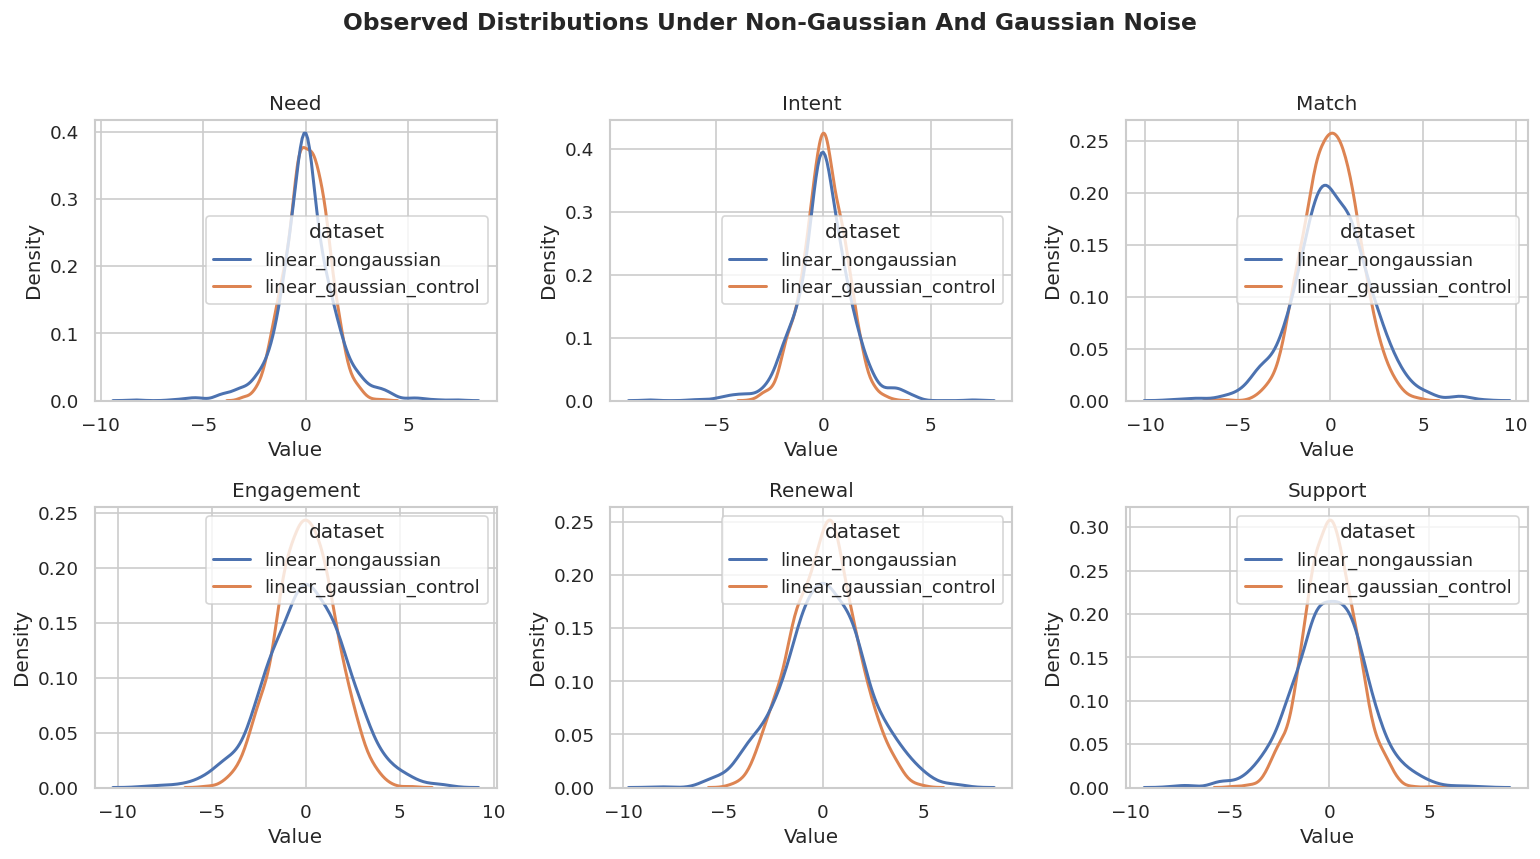

In [6]:
plot_df = pd.concat(
    [
        nongaussian_df.assign(dataset="linear_nongaussian"),
        gaussian_df.assign(dataset="linear_gaussian_control"),
    ],
    ignore_index=True,
).melt(id_vars="dataset", var_name="variable", value_name="value")

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=False)
for ax, variable in zip(axes.flat, VARIABLES):
    sns.kdeplot(
        data=plot_df[plot_df["variable"] == variable],
        x="value",
        hue="dataset",
        common_norm=False,
        fill=False,
        linewidth=1.8,
        ax=ax,
    )
    ax.set_title(variable.title())
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")

fig.suptitle("Observed Distributions Under Non-Gaussian And Gaussian Noise", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_observed_distribution_check.png", dpi=160, bbox_inches="tight")
plt.show()

The curves are not diagnostic by themselves, but they give useful context. If every variable looked perfectly Gaussian and the domain gave no reason to expect non-Gaussian errors, LiNGAM would be a harder sell as the primary discovery method.

## Helper Functions

This notebook needs three kinds of helpers: graph parsing, graph scoring, and graph drawing. The most important helper is `lingam_adjacency_to_edge_table`, which converts a LiNGAM coefficient matrix into a standard `source -> target` edge table. Remember that the raw LiNGAM matrix is indexed as child rows and parent columns.

In [7]:
def lingam_adjacency_to_edge_table(adjacency_matrix, variables, label, threshold=0.15):
    """Convert a LiNGAM child-row, parent-column matrix into a tidy directed edge table."""
    rows = []
    for child_idx, parent_idx in zip(*np.where(np.abs(adjacency_matrix) >= threshold)):
        rows.append(
            {
                "run": label,
                "source": variables[int(parent_idx)],
                "edge_type": "-->",
                "target": variables[int(child_idx)],
                "coefficient": float(adjacency_matrix[child_idx, parent_idx]),
                "abs_coefficient": float(abs(adjacency_matrix[child_idx, parent_idx])),
            }
        )
    columns = ["run", "source", "edge_type", "target", "coefficient", "abs_coefficient"]
    return pd.DataFrame(rows, columns=columns).sort_values(["source", "target"]).reset_index(drop=True)


def parse_causallearn_edge(edge):
    """Convert a causal-learn edge object into source, endpoint pattern, and target strings."""
    parts = str(edge).strip().split()
    if len(parts) != 3:
        return {"source": str(edge), "edge_type": "unknown", "target": "unknown"}
    return {"source": parts[0], "edge_type": parts[1], "target": parts[2]}


def graph_to_edge_table(graph, label):
    """Return a tidy edge table from a causal-learn graph object."""
    rows = [parse_causallearn_edge(edge) for edge in graph.get_graph_edges()]
    edge_df = pd.DataFrame(rows, columns=["source", "edge_type", "target"])
    if edge_df.empty:
        edge_df = pd.DataFrame(columns=["source", "edge_type", "target"])
    edge_df.insert(0, "run", label)
    return edge_df


def directed_pairs(edge_df):
    """Extract definite directed pairs from an edge table."""
    pairs = set()
    for row in edge_df.itertuples(index=False):
        if row.edge_type == "-->":
            pairs.add((row.source, row.target))
        elif row.edge_type == "<--":
            pairs.add((row.target, row.source))
    return pairs


def skeleton_pairs(edge_df):
    """Extract adjacencies while ignoring direction."""
    pairs = set()
    for row in edge_df.itertuples(index=False):
        if row.target != "unknown":
            pairs.add(frozenset([row.source, row.target]))
    return pairs


def summarize_against_truth(edge_df, truth_df, label):
    """Compute graph-recovery metrics against a directed truth table."""
    true_directed = set(zip(truth_df["source"], truth_df["target"]))
    true_skeleton = {frozenset(edge) for edge in true_directed}
    learned_directed = directed_pairs(edge_df)
    learned_skeleton = skeleton_pairs(edge_df)

    correct_directed = learned_directed & true_directed
    reversed_true = {(src, dst) for src, dst in true_directed if (dst, src) in learned_directed}
    missing_skeleton = true_skeleton - learned_skeleton
    extra_skeleton = learned_skeleton - true_skeleton

    unresolved_true = 0
    for src, dst in true_directed:
        pair = frozenset([src, dst])
        if pair in learned_skeleton and (src, dst) not in learned_directed and (dst, src) not in learned_directed:
            unresolved_true += 1

    directed_count = len(learned_directed)
    return pd.DataFrame(
        [
            {
                "run": label,
                "learned_edges_total": len(edge_df),
                "definite_directed_edges": directed_count,
                "true_edges": len(true_directed),
                "correct_directed_edges": len(correct_directed),
                "directed_precision": len(correct_directed) / directed_count if directed_count else np.nan,
                "directed_recall": len(correct_directed) / len(true_directed) if true_directed else np.nan,
                "reversed_true_edges": len(reversed_true),
                "unresolved_true_adjacencies": unresolved_true,
                "missing_true_adjacencies": len(missing_skeleton),
                "extra_adjacencies": len(extra_skeleton),
            }
        ]
    )


def run_pc_fisherz(data_df, label, alpha=0.01):
    """Run PC quietly with Fisher-Z tests."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = pc(
            data_df.to_numpy(),
            alpha=alpha,
            indep_test="fisherz",
            stable=True,
            verbose=False,
            show_progress=False,
            node_names=list(data_df.columns),
        )
    return result, graph_to_edge_table(result.G, label=label)


def run_ges_bic(data_df, label):
    """Run BIC-GES quietly for comparison."""
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        record = ges(
            data_df.to_numpy(),
            score_func="local_score_BIC",
            node_names=list(data_df.columns),
            lambda_value=0.5,
        )
    return record, graph_to_edge_table(record["G"], label=label)


GRAPH_POSITIONS = {
    "need": (0.11, 0.72),
    "intent": (0.11, 0.28),
    "match": (0.39, 0.50),
    "engagement": (0.62, 0.50),
    "renewal": (0.89, 0.72),
    "support": (0.89, 0.28),
}
NODE_LABELS = {name: name.title() for name in GRAPH_POSITIONS}
NODE_COLORS = {
    "need": "#e0f2fe",
    "intent": "#dbeafe",
    "match": "#ecfccb",
    "engagement": "#fef3c7",
    "renewal": "#fee2e2",
    "support": "#f3e8ff",
}


def trim_edge_to_box(start, end, box_w=0.145, box_h=0.095, gap=0.012):
    """Return edge endpoints that stop just outside source and target boxes."""
    x0, y0 = start
    x1, y1 = end
    dx = x1 - x0
    dy = y1 - y0
    length = float(np.hypot(dx, dy))
    if length == 0:
        return start, end
    effective_w = box_w + 0.04
    effective_h = box_h + 0.04
    x_limit = (effective_w / 2) / abs(dx) if dx else np.inf
    y_limit = (effective_h / 2) / abs(dy) if dy else np.inf
    t = min(x_limit, y_limit) + gap / length
    return (x0 + dx * t, y0 + dy * t), (x1 - dx * t, y1 - dy * t)


def draw_box_graph(edge_df, title, path, note=None):
    """Draw a DAG-style graph with rounded boxes and visible arrowheads."""
    fig, ax = plt.subplots(figsize=(12, 6.2))
    ax.set_axis_off()
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(0.04, 0.96)
    box_w, box_h = 0.145, 0.095

    for row in edge_df.itertuples(index=False):
        if row.source not in GRAPH_POSITIONS or row.target not in GRAPH_POSITIONS:
            continue
        raw_start = GRAPH_POSITIONS[row.source]
        raw_end = GRAPH_POSITIONS[row.target]
        if row.edge_type == "<--":
            raw_start, raw_end = raw_end, raw_start
        start, end = trim_edge_to_box(raw_start, raw_end, box_w=box_w, box_h=box_h)
        if row.edge_type in {"-->", "<--"}:
            arrowstyle = "-|>"
            mutation_scale = 18
            linewidth = 1.8
            color = "#334155"
        else:
            arrowstyle = "-"
            mutation_scale = 1
            linewidth = 1.5
            color = "#64748b"
        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle=arrowstyle,
            mutation_scale=mutation_scale,
            linewidth=linewidth,
            color=color,
            connectionstyle="arc3,rad=0.035",
            zorder=2,
        )
        ax.add_patch(arrow)

    for node, (x, y) in GRAPH_POSITIONS.items():
        rect = FancyBboxPatch(
            (x - box_w / 2, y - box_h / 2),
            box_w,
            box_h,
            boxstyle="round,pad=0.018",
            facecolor=NODE_COLORS[node],
            edgecolor="#1f2937",
            linewidth=1.1,
            zorder=5,
        )
        ax.add_patch(rect)
        ax.text(x, y, NODE_LABELS[node], ha="center", va="center", fontsize=10.5, fontweight="bold", zorder=6)

    if note:
        ax.text(0.50, 0.08, note, ha="center", va="center", fontsize=10, color="#475569")
    ax.set_title(title, pad=18, fontsize=14, fontweight="bold")
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


def truth_as_edge_table(truth_df, label="truth"):
    """Convert the truth table into a plotting-ready edge table."""
    return truth_df.assign(run=label, edge_type="-->")[["run", "source", "edge_type", "target"]]

These helpers make the rest of the notebook easier to read. The same metric definitions are used for LiNGAM, PC, and GES so the comparison stays apples-to-apples.

## Draw The True DAG

Before looking at learned graphs, we draw the true graph used to create the data. This anchors the rest of the notebook: every learned edge table and metric table will be compared back to this DAG.

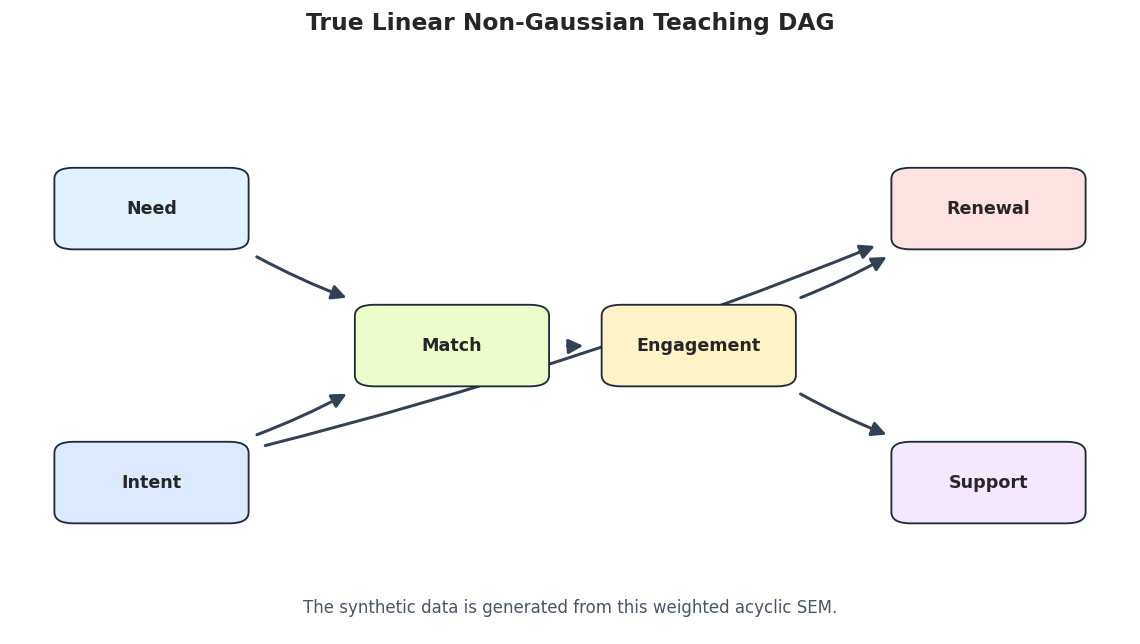

In [8]:
true_plot_edges = truth_as_edge_table(true_edge_table)
draw_box_graph(
    true_plot_edges,
    title="True Linear Non-Gaussian Teaching DAG",
    path=FIGURE_DIR / f"{NOTEBOOK_PREFIX}_true_lingam_dag.png",
    note="The synthetic data is generated from this weighted acyclic SEM.",
)

The graph has six directed edges and no cycles. LiNGAM will try to recover both this ordering and the direct linear coefficients from the observed data alone.

## A Tiny Directionality Demo

A two-variable system is the cleanest way to see why LiNGAM is useful. If `cause` and `effect` are merely dependent, PC and GES have no collider or larger graph pattern that forces an orientation. With non-Gaussian linear noise, LiNGAM can use distributional asymmetry to choose a direction.

In [9]:
rng = np.random.default_rng(101)
pair_n = 1_000
cause = rng.laplace(size=pair_n)
effect = 0.90 * cause + rng.laplace(size=pair_n)
pair_df = pd.DataFrame({"cause": cause, "effect": effect})

pair_lingam = DirectLiNGAM(random_state=101)
pair_lingam.fit(pair_df.to_numpy())
pair_lingam_edges = lingam_adjacency_to_edge_table(
    pair_lingam.adjacency_matrix_,
    list(pair_df.columns),
    label="DirectLiNGAM_pair",
    threshold=0.15,
)

pair_pc, pair_pc_edges = run_pc_fisherz(pair_df, label="PC_pair", alpha=0.01)
pair_ges, pair_ges_edges = run_ges_bic(pair_df, label="GES_pair")

pair_demo = pd.concat(
    [
        pair_lingam_edges[["run", "source", "edge_type", "target"]],
        pair_pc_edges,
        pair_ges_edges,
    ],
    ignore_index=True,
)
pair_demo.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_two_variable_direction_demo.csv", index=False)
display(pair_demo)

,run,source,edge_type,target
0,DirectLiNGAM_pair,cause,-->,effect
1,PC_pair,cause,---,effect
2,GES_pair,cause,---,effect


In this two-variable example, PC and GES usually report an unoriented adjacency because both directions fit the same conditional independence pattern. DirectLiNGAM can orient the edge because the data was generated by a linear model with independent non-Gaussian errors.

## Fit DirectLiNGAM And ICA-LiNGAM

Now we fit the two core LiNGAM estimators available in `causal-learn`. `DirectLiNGAM` estimates the causal order directly through independence comparisons. `ICALiNGAM` uses independent component analysis and then searches for a causal ordering compatible with the estimated mixing structure.

We use a coefficient threshold of `0.15` for graph reporting. The raw coefficient matrices are saved separately, so the threshold is only a reporting choice, not a hidden model change.

In [10]:
EDGE_THRESHOLD = 0.15

model_specs = [
    ("DirectLiNGAM", DirectLiNGAM(random_state=42)),
    ("ICALiNGAM", ICALiNGAM(random_state=42, max_iter=3_000)),
]

lingam_rows = []
lingam_edges = []
lingam_metrics = []
lingam_matrices = {}

for label, model in model_specs:
    start = time.perf_counter()
    model.fit(nongaussian_df.to_numpy())
    elapsed = time.perf_counter() - start

    edge_table = lingam_adjacency_to_edge_table(
        model.adjacency_matrix_,
        VARIABLES,
        label=label,
        threshold=EDGE_THRESHOLD,
    )
    metric_table = summarize_against_truth(edge_table, true_edge_table, label=label)
    metric_table["elapsed_seconds"] = elapsed

    lingam_rows.append(
        {
            "model": label,
            "elapsed_seconds": elapsed,
            "causal_order": " -> ".join(VARIABLES[int(idx)] for idx in model.causal_order_),
            "reported_edges": len(edge_table),
            "threshold": EDGE_THRESHOLD,
        }
    )
    lingam_edges.append(edge_table)
    lingam_metrics.append(metric_table)
    lingam_matrices[label] = pd.DataFrame(model.adjacency_matrix_, index=VARIABLES, columns=VARIABLES)

lingam_model_summary = pd.DataFrame(lingam_rows)
lingam_edge_table = pd.concat(lingam_edges, ignore_index=True)
lingam_metric_table = pd.concat(lingam_metrics, ignore_index=True)

lingam_model_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_lingam_model_summary.csv", index=False)
lingam_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_lingam_edges.csv", index=False)
lingam_metric_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_lingam_metrics.csv", index=False)
for label, matrix in lingam_matrices.items():
    matrix.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_{label.lower()}_coefficient_matrix.csv")

display(lingam_model_summary.round(4))
display(lingam_edge_table.round(4))
display(lingam_metric_table.round(4))

,model,elapsed_seconds,causal_order,reported_edges,threshold
0,DirectLiNGAM,0.0241,need -> intent -> match -> engagement -> suppo...,6,0.15
1,ICALiNGAM,0.0092,need -> intent -> match -> engagement -> renew...,6,0.15


,run,source,edge_type,target,coefficient,abs_coefficient
0,DirectLiNGAM,engagement,-->,renewal,0.6423,0.6423
1,DirectLiNGAM,engagement,-->,support,0.5742,0.5742
2,DirectLiNGAM,intent,-->,match,0.7007,0.7007
3,DirectLiNGAM,intent,-->,renewal,0.3031,0.3031
4,DirectLiNGAM,match,-->,engagement,0.8487,0.8487
5,DirectLiNGAM,need,-->,match,0.7745,0.7745
6,ICALiNGAM,engagement,-->,renewal,0.6418,0.6418
7,ICALiNGAM,engagement,-->,support,0.5739,0.5739
8,ICALiNGAM,intent,-->,match,0.7007,0.7007
9,ICALiNGAM,intent,-->,renewal,0.3142,0.3142


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies,elapsed_seconds
0,DirectLiNGAM,6,6,6,6,1.0,1.0,0,0,0,0,0.0241
1,ICALiNGAM,6,6,6,6,1.0,1.0,0,0,0,0,0.0092


On this aligned synthetic example, both LiNGAM estimators should recover the main direct edges with coefficients close to the data-generating values. Small ordering differences among downstream variables can happen when those variables are not direct ancestors of each other.

## Learned DirectLiNGAM Graph

The edge table is precise, but a graph is easier to scan. This figure shows the thresholded DirectLiNGAM graph using the same visual style as the rest of the tutorial series.

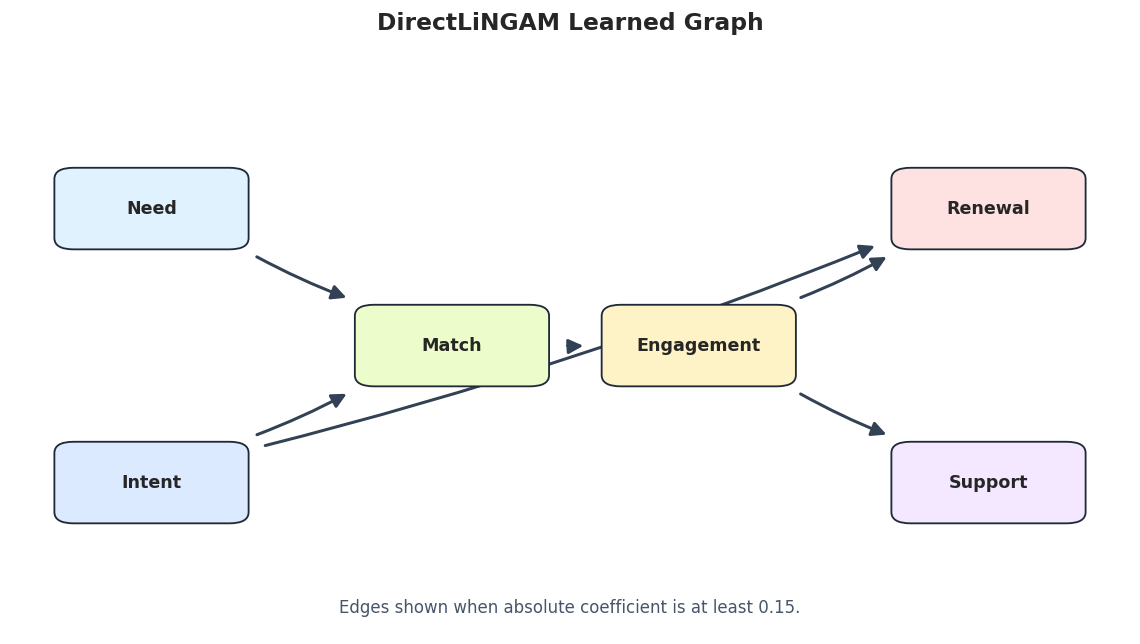

In [11]:
direct_lingam_edges = lingam_edge_table[lingam_edge_table["run"] == "DirectLiNGAM"].copy()
draw_box_graph(
    direct_lingam_edges,
    title="DirectLiNGAM Learned Graph",
    path=FIGURE_DIR / f"{NOTEBOOK_PREFIX}_direct_lingam_graph.png",
    note=f"Edges shown when absolute coefficient is at least {EDGE_THRESHOLD}.",
)

The graph should line up closely with the true DAG. The plot is thresholded for readability, while the coefficient matrices below retain the full numerical output.

## Compare Estimated Coefficients To True Coefficients

LiNGAM gives signed direct-effect coefficients, which is one reason it is useful in linear systems. Here we stack the true matrix, DirectLiNGAM matrix, and ICA-LiNGAM matrix into one tidy table and a heatmap.

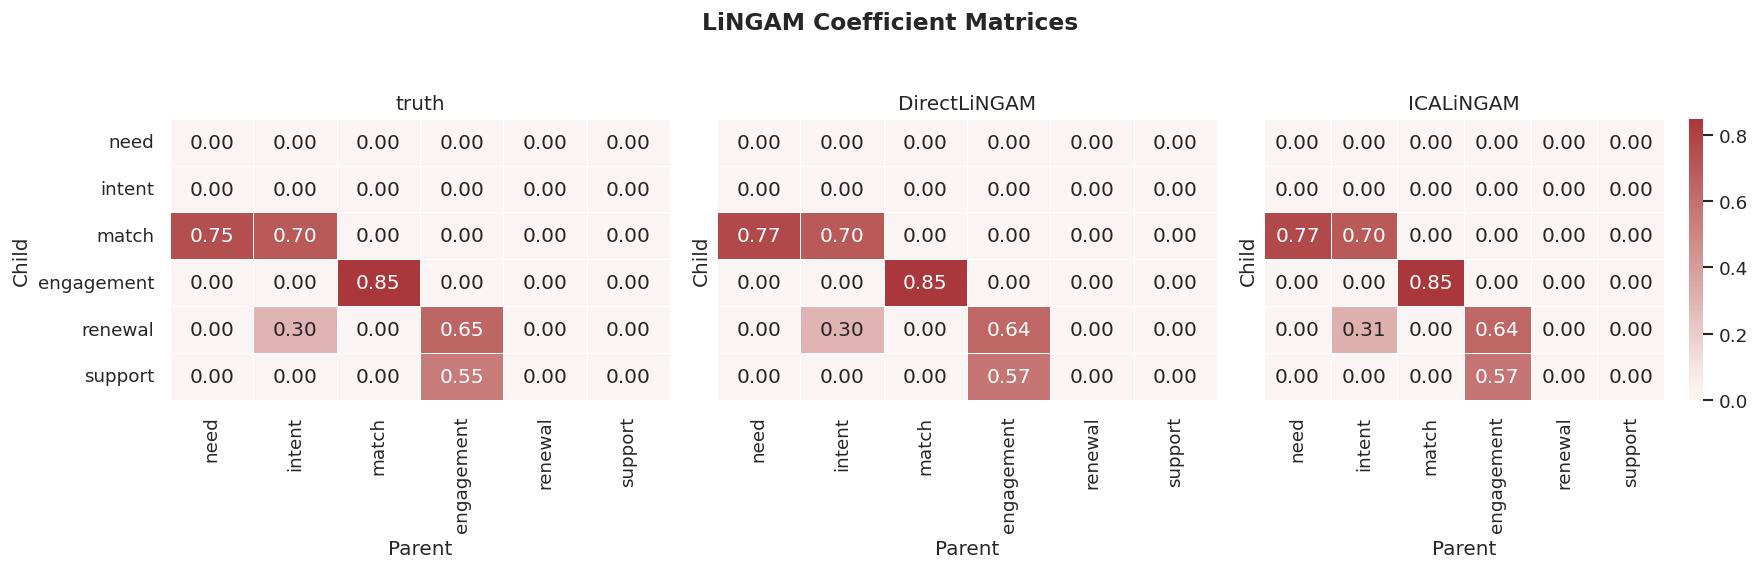

In [12]:
coefficient_long = []
for matrix_label, matrix in [("truth", true_coefficient_matrix), *lingam_matrices.items()]:
    matrix_df = pd.DataFrame(matrix, index=VARIABLES, columns=VARIABLES)
    for child in VARIABLES:
        for parent in VARIABLES:
            coefficient_long.append(
                {
                    "matrix": matrix_label,
                    "parent": parent,
                    "child": child,
                    "coefficient": float(matrix_df.loc[child, parent]),
                }
            )

coefficient_long = pd.DataFrame(coefficient_long)
coefficient_long.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_coefficient_long.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True, sharey=True)
for ax, matrix_label in zip(axes, ["truth", "DirectLiNGAM", "ICALiNGAM"]):
    heatmap_data = coefficient_long[coefficient_long["matrix"] == matrix_label].pivot(
        index="child", columns="parent", values="coefficient"
    ).loc[VARIABLES, VARIABLES]
    sns.heatmap(
        heatmap_data,
        cmap="vlag",
        center=0,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        cbar=ax is axes[-1],
        ax=ax,
    )
    ax.set_title(matrix_label)
    ax.set_xlabel("Parent")
    ax.set_ylabel("Child")

fig.suptitle("LiNGAM Coefficient Matrices", y=1.03, fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_coefficient_matrices.png", dpi=160, bbox_inches="tight")
plt.show()

The heatmap is the safest way to read LiNGAM coefficients because it preserves orientation: parent variables are columns and child variables are rows. The strongest learned coefficients should sit in the same cells as the true nonzero coefficients.

## Causal Order Check

LiNGAM estimates a causal order as part of the model. Exact order is stricter than edge recovery: two variables that are not ancestors of each other can swap without changing the direct edge graph. This table compares the true order ranks with the estimated order ranks.

In [13]:
true_order = ["need", "intent", "match", "engagement", "renewal", "support"]
order_rows = []
for model_label, model in model_specs:
    estimated_order = [VARIABLES[int(idx)] for idx in model.causal_order_]
    for variable in VARIABLES:
        order_rows.append(
            {
                "model": model_label,
                "variable": variable,
                "true_rank": true_order.index(variable) + 1,
                "estimated_rank": estimated_order.index(variable) + 1,
                "rank_difference": (estimated_order.index(variable) + 1) - (true_order.index(variable) + 1),
            }
        )

order_table = pd.DataFrame(order_rows)
order_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_causal_order_comparison.csv", index=False)
display(order_table)

,model,variable,true_rank,estimated_rank,rank_difference
0,DirectLiNGAM,need,1,1,0
1,DirectLiNGAM,intent,2,2,0
2,DirectLiNGAM,match,3,3,0
3,DirectLiNGAM,engagement,4,4,0
4,DirectLiNGAM,renewal,5,6,1
5,DirectLiNGAM,support,6,5,-1
6,ICALiNGAM,need,1,1,0
7,ICALiNGAM,intent,2,2,0
8,ICALiNGAM,match,3,3,0
9,ICALiNGAM,engagement,4,4,0


The order table should be read with nuance. Getting a root before its descendants matters; swapping two unrelated downstream variables is usually less important than reversing a true parent-child relationship.

## Residual Independence Check

After fitting a LiNGAM model, we can compute residuals implied by the learned structural equations and test whether those residuals look mutually independent. This is closer to the actual LiNGAM assumption than checking observed-variable distributions, although it still remains a diagnostic rather than a proof.

,need,intent,match,engagement,renewal,support
need,0.0000,0.0043,0.5934,0.6026,0.1266,0.1675
intent,0.0043,0.0000,0.9262,0.2998,0.5931,0.1790
match,0.5934,0.9262,0.0000,0.8151,0.4098,0.5645
engagement,0.6026,0.2998,0.8151,0.0000,0.4542,0.3548
renewal,0.1266,0.5931,0.4098,0.4542,0.0000,0.4698
support,0.1675,0.1790,0.5645,0.3548,0.4698,0.0000


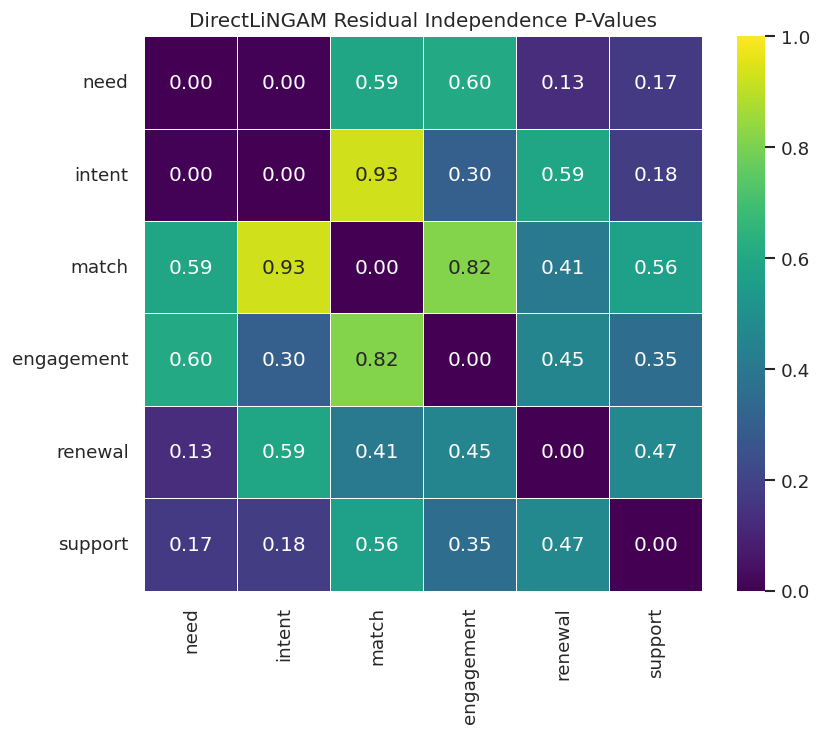

In [14]:
direct_model = model_specs[0][1]
residual_p_values = pd.DataFrame(
    direct_model.get_error_independence_p_values(nongaussian_df.to_numpy()),
    index=VARIABLES,
    columns=VARIABLES,
)
residual_p_values.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_direct_lingam_residual_independence_p_values.csv")

display(residual_p_values.round(4))

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(
    residual_p_values,
    cmap="viridis",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("DirectLiNGAM Residual Independence P-Values")
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_residual_independence_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

Large off-diagonal p-values are more comfortable for the LiNGAM story because they suggest the fitted residuals are not obviously dependent. Isolated small p-values are a cue to inspect model fit, omitted variables, nonlinearities, or threshold choices.

## Bootstrap Edge Stability

A single fitted graph can look cleaner than the uncertainty behind it. Bootstrap resampling repeatedly refits DirectLiNGAM on resampled rows and records how often each edge appears. This is a practical stability check for the discovered directions.

In [15]:
BOOTSTRAP_SAMPLES = 25
bootstrap_start = time.perf_counter()
bootstrap_result = DirectLiNGAM(random_state=42).bootstrap(nongaussian_df.to_numpy(), BOOTSTRAP_SAMPLES)
bootstrap_elapsed = time.perf_counter() - bootstrap_start

bootstrap_probability_matrix = bootstrap_result.get_probabilities(min_causal_effect=EDGE_THRESHOLD)
bootstrap_probability_df = pd.DataFrame(bootstrap_probability_matrix, index=VARIABLES, columns=VARIABLES)
bootstrap_probability_df.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_bootstrap_probability_matrix.csv")

direction_counts = bootstrap_result.get_causal_direction_counts(
    n_directions=12,
    min_causal_effect=EDGE_THRESHOLD,
    split_by_causal_effect_sign=False,
)
direction_count_table = pd.DataFrame(direction_counts)
direction_count_table["from"] = direction_count_table["from"].map(lambda idx: VARIABLES[int(idx)])
direction_count_table["to"] = direction_count_table["to"].map(lambda idx: VARIABLES[int(idx)])
direction_count_table["probability"] = direction_count_table["count"] / BOOTSTRAP_SAMPLES
direction_count_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_bootstrap_direction_counts.csv", index=False)

bootstrap_summary = pd.DataFrame(
    [
        {
            "bootstrap_samples": BOOTSTRAP_SAMPLES,
            "elapsed_seconds": bootstrap_elapsed,
            "coefficient_threshold": EDGE_THRESHOLD,
        }
    ]
)
bootstrap_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_bootstrap_summary.csv", index=False)

display(bootstrap_summary.round(4))
display(direction_count_table)

,bootstrap_samples,elapsed_seconds,coefficient_threshold
0,25,1.1591,0.15


,from,to,count,probability
0,need,match,25,1.0
1,intent,match,25,1.0
2,match,engagement,25,1.0
3,intent,renewal,25,1.0
4,engagement,renewal,25,1.0
5,engagement,support,25,1.0


Edges with high bootstrap probability are more stable under row resampling. Low-probability edges should not be promoted to strong causal claims, even when they appear in one fitted graph.

## Bootstrap Probability Heatmap

The bootstrap matrix has the same child-row, parent-column orientation as the coefficient matrix. Bright cells mean that a parent-child direction appeared in many bootstrap runs.

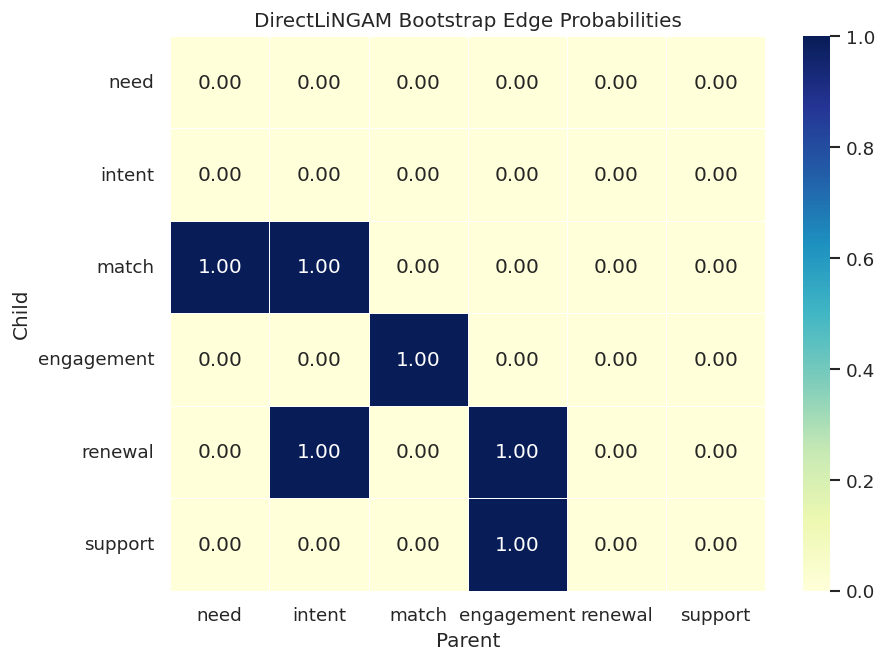

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    bootstrap_probability_df.loc[VARIABLES, VARIABLES],
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("DirectLiNGAM Bootstrap Edge Probabilities")
ax.set_xlabel("Parent")
ax.set_ylabel("Child")
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_bootstrap_edge_probabilities.png", dpi=160, bbox_inches="tight")
plt.show()

The true direct edges should have high probability in this controlled example. Any nonzero probability on a false edge is useful too: it tells us where the estimator occasionally sees a weak alternative explanation.

## Total Effects And Paths

Direct coefficients describe immediate parent-child effects. LiNGAM can also estimate total effects along directed paths. Here we inspect total effects and the paths from `need` to `renewal`, where the true main route is `need -> match -> engagement -> renewal`.

In [17]:
total_effects = bootstrap_result.get_total_causal_effects(min_causal_effect=EDGE_THRESHOLD)
total_effect_table = pd.DataFrame(total_effects)
if not total_effect_table.empty:
    total_effect_table["from"] = total_effect_table["from"].map(lambda idx: VARIABLES[int(idx)])
    total_effect_table["to"] = total_effect_table["to"].map(lambda idx: VARIABLES[int(idx)])
total_effect_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_bootstrap_total_effects.csv", index=False)

paths = bootstrap_result.get_paths(
    from_index=VARIABLES.index("need"),
    to_index=VARIABLES.index("renewal"),
    min_causal_effect=0.25,
)
path_table = pd.DataFrame(paths)
if not path_table.empty:
    path_table["path_labels"] = path_table["path"].apply(lambda path: " -> ".join(VARIABLES[int(idx)] for idx in path))
path_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_need_to_renewal_paths.csv", index=False)

display(total_effect_table.head(12).round(4))
display(path_table.round(4))

,from,to,effect,probability
0,need,match,0.7724,1.0
1,intent,match,0.6980,1.0
2,need,engagement,0.6504,1.0
3,intent,engagement,0.6454,1.0
4,match,engagement,0.8487,1.0
5,need,renewal,0.4282,1.0
6,intent,renewal,0.7289,1.0
7,match,renewal,0.5403,1.0
8,engagement,renewal,0.6469,1.0
9,need,support,0.3438,1.0


,path,effect,probability,path_labels
0,"[0, 2, 3, 4]",0.4123,1.00,need -> match -> engagement -> renewal
1,"[0, 2, 3, 5, 4]",0.0279,0.20,need -> match -> engagement -> support -> renewal
2,"[0, 2, 4]",0.0571,0.04,need -> match -> renewal
3,"[0, 5, 4]",-0.0049,0.04,need -> support -> renewal


Total effects can be helpful for decision questions, but they inherit every assumption behind the learned graph. In this notebook they are teaching diagnostics; in real work they should be paired with domain review and robustness checks.

## Compare LiNGAM With PC And GES

PC, GES, and LiNGAM answer related but different discovery questions. PC searches for conditional independence structure. GES searches over graph scores. LiNGAM uses a linear non-Gaussian structural model. Running them side by side helps separate discoveries that are robust across families from discoveries that depend heavily on one assumption set.

In [18]:
pc_result, pc_edges = run_pc_fisherz(nongaussian_df, label="PC_FisherZ", alpha=0.01)
ges_result, ges_edges = run_ges_bic(nongaussian_df, label="GES_BIC")

comparison_edges = pd.concat(
    [
        direct_lingam_edges[["run", "source", "edge_type", "target"]],
        pc_edges,
        ges_edges,
    ],
    ignore_index=True,
)
comparison_metrics = pd.concat(
    [
        summarize_against_truth(direct_lingam_edges, true_edge_table, "DirectLiNGAM"),
        summarize_against_truth(pc_edges, true_edge_table, "PC_FisherZ"),
        summarize_against_truth(ges_edges, true_edge_table, "GES_BIC"),
    ],
    ignore_index=True,
)

comparison_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_lingam_pc_ges_edges.csv", index=False)
comparison_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_lingam_pc_ges_metrics.csv", index=False)

display(comparison_edges)
display(comparison_metrics.round(4))

,run,source,edge_type,target
0,DirectLiNGAM,engagement,-->,renewal
1,DirectLiNGAM,engagement,-->,support
2,DirectLiNGAM,intent,-->,match
3,DirectLiNGAM,intent,-->,renewal
4,DirectLiNGAM,match,-->,engagement
5,DirectLiNGAM,need,-->,match
6,PC_FisherZ,need,-->,match
7,PC_FisherZ,intent,-->,match
8,PC_FisherZ,intent,-->,renewal
9,PC_FisherZ,match,-->,engagement


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,DirectLiNGAM,6,6,6,6,1.0,1.0,0,0,0,0
1,PC_FisherZ,6,6,6,6,1.0,1.0,0,0,0,0
2,GES_BIC,6,6,6,6,1.0,1.0,0,0,0,0


On this clean six-variable system, all three methods may do well because the graph has enough structure to orient the key edges. The two-variable demo above is the sharper example of LiNGAM's directional advantage.

## Plot Method-Level Metrics

A compact metric plot makes it easier to compare recovery patterns across algorithm families. The bars focus on directed recovery and adjacency mistakes rather than coefficient accuracy.

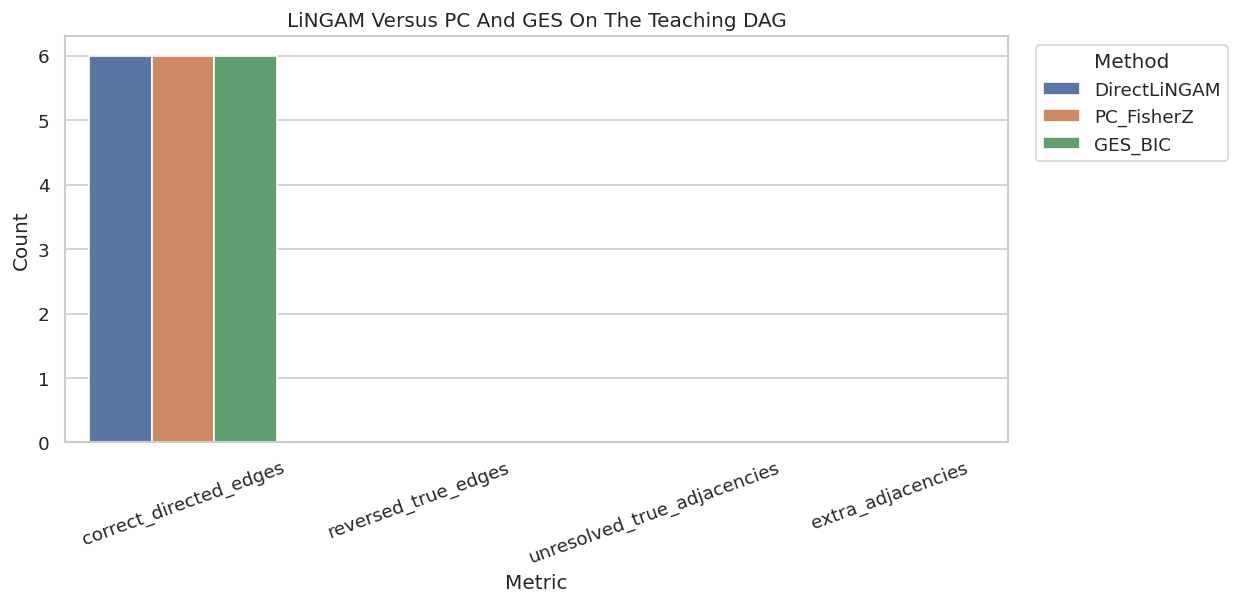

In [19]:
metric_plot_df = comparison_metrics.melt(
    id_vars="run",
    value_vars=["correct_directed_edges", "reversed_true_edges", "unresolved_true_adjacencies", "extra_adjacencies"],
    var_name="metric",
    value_name="count",
)

fig, ax = plt.subplots(figsize=(10.5, 5.2))
sns.barplot(data=metric_plot_df, x="metric", y="count", hue="run", ax=ax)
ax.set_title("LiNGAM Versus PC And GES On The Teaching DAG")
ax.set_xlabel("Metric")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_method_comparison_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

When several methods agree, the edge is easier to trust as a structural hypothesis. When they disagree, the next step is not to vote blindly; it is to ask which assumptions are most credible for the domain and dataset.

## Threshold Sensitivity

LiNGAM returns dense numerical coefficient matrices. Reporting requires a threshold, and thresholds can change the edge set. This cell reruns the graph metrics across several absolute-coefficient thresholds for DirectLiNGAM.

In [20]:
threshold_rows = []
threshold_edges = []
for threshold in [0.05, 0.10, 0.15, 0.20, 0.30, 0.45]:
    edge_table = lingam_adjacency_to_edge_table(
        direct_model.adjacency_matrix_,
        VARIABLES,
        label=f"threshold_{threshold:.2f}",
        threshold=threshold,
    )
    metric_table = summarize_against_truth(edge_table, true_edge_table, label=f"threshold_{threshold:.2f}")
    metric_table["threshold"] = threshold
    threshold_rows.append(metric_table)
    edge_table["threshold"] = threshold
    threshold_edges.append(edge_table)

threshold_metrics = pd.concat(threshold_rows, ignore_index=True)
threshold_edge_table = pd.concat(threshold_edges, ignore_index=True)
threshold_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_threshold_sensitivity_metrics.csv", index=False)
threshold_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_threshold_sensitivity_edges.csv", index=False)
display(threshold_metrics.round(4))

,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies,threshold
0,threshold_0.05,6,6,6,6,1.0,1.0000,0,0,0,0,0.05
1,threshold_0.10,6,6,6,6,1.0,1.0000,0,0,0,0,0.10
2,threshold_0.15,6,6,6,6,1.0,1.0000,0,0,0,0,0.15
3,threshold_0.20,6,6,6,6,1.0,1.0000,0,0,0,0,0.20
4,threshold_0.30,6,6,6,6,1.0,1.0000,0,0,0,0,0.30
5,threshold_0.45,5,5,6,5,1.0,0.8333,0,0,1,0,0.45


A good threshold should remove tiny unstable coefficients without deleting meaningful true edges. In real data, this table should be shown alongside bootstrap probabilities rather than used as a standalone tuning exercise.

## Plot Threshold Sensitivity

This plot shows how the reported graph changes as the coefficient threshold becomes more conservative.

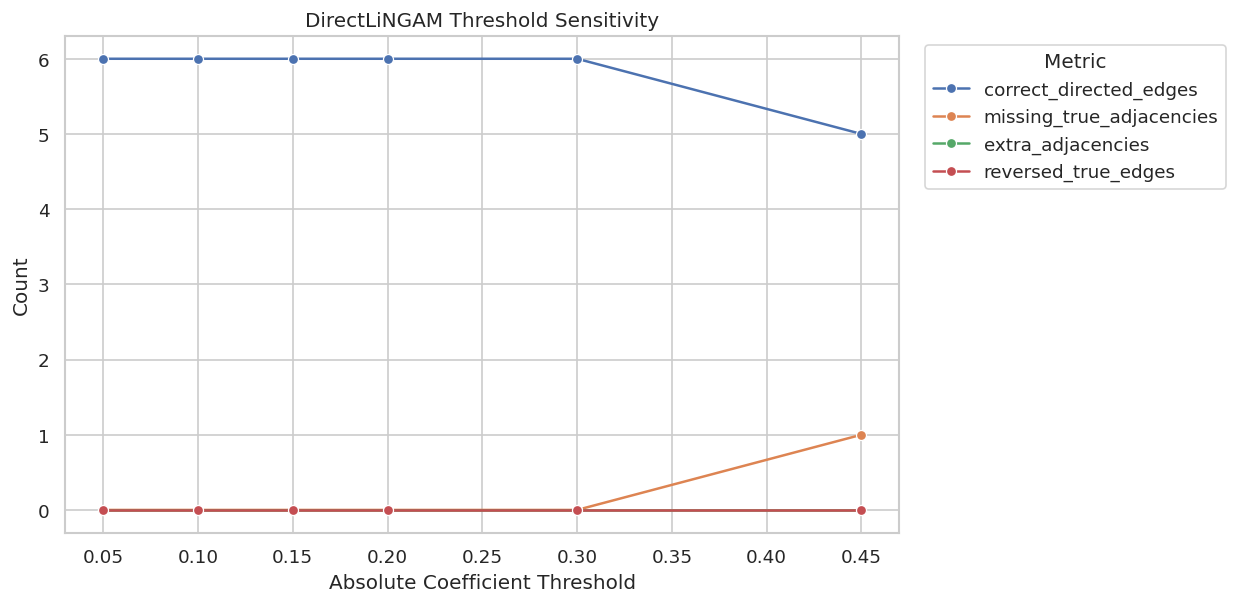

In [21]:
threshold_plot_df = threshold_metrics.melt(
    id_vars=["run", "threshold"],
    value_vars=["correct_directed_edges", "missing_true_adjacencies", "extra_adjacencies", "reversed_true_edges"],
    var_name="metric",
    value_name="count",
)

fig, ax = plt.subplots(figsize=(10.5, 5.2))
sns.lineplot(data=threshold_plot_df, x="threshold", y="count", hue="metric", marker="o", ax=ax)
ax.set_title("DirectLiNGAM Threshold Sensitivity")
ax.set_xlabel("Absolute Coefficient Threshold")
ax.set_ylabel("Count")
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_threshold_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

The curve helps expose brittle conclusions. If one edge appears only at a very permissive threshold and has low bootstrap probability, it should be treated as exploratory rather than central.

## Gaussian Control Stress Test

LiNGAM is designed for non-Gaussian errors. To see why that matters, we repeatedly simulate the same structural graph under Laplace and Gaussian errors, fit DirectLiNGAM, and compare recovery metrics. The coefficient structure is unchanged; only the noise family changes.

In [22]:
stress_rows = []
for noise_family in ["laplace", "gaussian"]:
    for seed in range(20, 30):
        simulated_df = simulate_linear_system(n_samples=800, noise=noise_family, seed=seed)
        model = DirectLiNGAM(random_state=seed)
        model.fit(simulated_df.to_numpy())
        edge_table = lingam_adjacency_to_edge_table(
            model.adjacency_matrix_,
            VARIABLES,
            label=f"{noise_family}_{seed}",
            threshold=EDGE_THRESHOLD,
        )
        metrics = summarize_against_truth(edge_table, true_edge_table, label=f"{noise_family}_{seed}")
        metrics["noise_family"] = noise_family
        metrics["seed"] = seed
        stress_rows.append(metrics)

noise_stress_metrics = pd.concat(stress_rows, ignore_index=True)
noise_stress_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_noise_family_stress_metrics.csv", index=False)

display(
    noise_stress_metrics.groupby("noise_family")[[
        "correct_directed_edges",
        "reversed_true_edges",
        "missing_true_adjacencies",
        "extra_adjacencies",
    ]]
    .agg(["mean", "min", "max"])
    .round(3)
)

correct_directed_edges         reversed_true_edges          \
                               mean min max                mean min max   
noise_family                                                              
gaussian                        2.9   1   5                 3.0   1   5   
laplace                         6.0   6   6                 0.0   0   0   

             missing_true_adjacencies         extra_adjacencies          
                                 mean min max              mean min max  
noise_family                                                             
gaussian                          0.1   0   1               3.5   1   6  
laplace                           0.0   0   0               0.0   0   0

The stress test is intentionally small, but it makes the assumption visible. If the Gaussian-control results are less stable, that is not a bug in LiNGAM; it is the model telling us that its identifying information has been weakened.

## Plot The Noise-Family Stress Test

The grouped summary above is useful, but a plot shows the run-to-run spread more clearly.

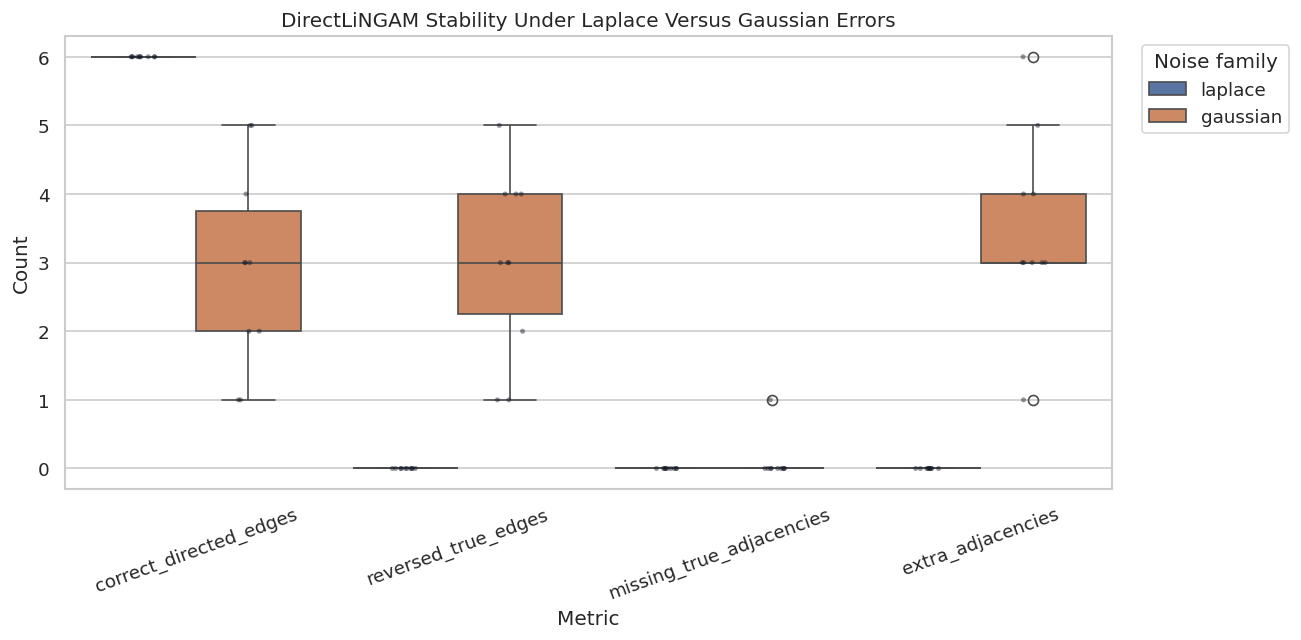

In [23]:
noise_plot_df = noise_stress_metrics.melt(
    id_vars=["run", "noise_family", "seed"],
    value_vars=["correct_directed_edges", "reversed_true_edges", "missing_true_adjacencies", "extra_adjacencies"],
    var_name="metric",
    value_name="count",
)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(data=noise_plot_df, x="metric", y="count", hue="noise_family", ax=ax)
sns.stripplot(
    data=noise_plot_df,
    x="metric",
    y="count",
    hue="noise_family",
    dodge=True,
    palette={"laplace": "#111827", "gaussian": "#111827"},
    alpha=0.45,
    size=3,
    legend=False,
    ax=ax,
)
ax.set_title("DirectLiNGAM Stability Under Laplace Versus Gaussian Errors")
ax.set_xlabel("Metric")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Noise family", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_noise_family_stress_test.png", dpi=160, bbox_inches="tight")
plt.show()

This is the practical habit to build: whenever a method depends on a strong assumption, create a stress test that changes that assumption while holding the structural story fixed. It makes the model's comfort zone concrete.

## Practical Reporting Checklist

A LiNGAM report should be more than a graph screenshot. This checklist records the minimum context needed for a reader to understand what was estimated, why the method was plausible, and where the result is fragile.

In [24]:
reporting_checklist = pd.DataFrame(
    [
        {
            "item": "State the structural assumptions",
            "what_to_report": "Linearity, acyclicity, independent errors, and non-Gaussianity.",
            "why_it_matters": "These assumptions are what allow LiNGAM to orient edges beyond Markov equivalence.",
        },
        {
            "item": "Show distribution diagnostics",
            "what_to_report": "Skewness, excess kurtosis, normality checks, and domain reasons for non-Gaussian errors.",
            "why_it_matters": "Observed diagnostics cannot prove the assumption, but they can reveal obvious mismatch.",
        },
        {
            "item": "Report matrix orientation",
            "what_to_report": "Rows are children and columns are parents in the LiNGAM adjacency matrix.",
            "why_it_matters": "Misreading matrix orientation reverses causal stories.",
        },
        {
            "item": "Save threshold sensitivity",
            "what_to_report": "Edge sets and metrics under multiple coefficient thresholds.",
            "why_it_matters": "Small coefficients should not quietly drive major claims.",
        },
        {
            "item": "Use stability diagnostics",
            "what_to_report": "Bootstrap edge probabilities, path probabilities, and method comparisons.",
            "why_it_matters": "Stable edges are more credible than one-run artifacts.",
        },
        {
            "item": "Compare with other discovery families",
            "what_to_report": "Agreement and disagreement with PC, GES, or domain-constrained alternatives.",
            "why_it_matters": "Disagreement reveals assumption-sensitive conclusions.",
        },
    ]
)
reporting_checklist.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_lingam_reporting_checklist.csv", index=False)
display(reporting_checklist)

,item,what_to_report,why_it_matters
0,State the structural assumptions,"Linearity, acyclicity, independent errors, and...",These assumptions are what allow LiNGAM to ori...
1,Show distribution diagnostics,"Skewness, excess kurtosis, normality checks, a...",Observed diagnostics cannot prove the assumpti...
2,Report matrix orientation,Rows are children and columns are parents in t...,Misreading matrix orientation reverses causal ...
3,Save threshold sensitivity,Edge sets and metrics under multiple coefficie...,Small coefficients should not quietly drive ma...
4,Use stability diagnostics,"Bootstrap edge probabilities, path probabiliti...",Stable edges are more credible than one-run ar...
5,Compare with other discovery families,"Agreement and disagreement with PC, GES, or do...",Disagreement reveals assumption-sensitive conc...


The checklist is deliberately practical. In a portfolio or production-style analysis, the graph is only one output; the assumption audit and stability checks are what make the graph defensible.

## Artifact Manifest

The final cell lists the files produced by this notebook. This makes it easier to find the generated datasets, tables, and figures without searching the output directory manually.

In [25]:
artifact_rows = []
for folder, artifact_type in [(DATASET_DIR, "dataset"), (TABLE_DIR, "table"), (FIGURE_DIR, "figure")]:
    for artifact_path in sorted(folder.glob(f"{NOTEBOOK_PREFIX}_*")):
        artifact_rows.append(
            {
                "artifact_type": artifact_type,
                "path": str(artifact_path.relative_to(NOTEBOOK_DIR)),
                "size_kb": round(artifact_path.stat().st_size / 1024, 2),
            }
        )

artifact_manifest = pd.DataFrame(artifact_rows)
artifact_manifest.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_artifact_manifest.csv", index=False)
display(artifact_manifest)

,artifact_type,path,size_kb
0,dataset,outputs/datasets/10_linear_gaussian_control.csv,137.19
1,dataset,outputs/datasets/10_linear_nongaussian.csv,136.71
2,table,outputs/tables/10_artifact_manifest.csv,2.15
3,table,outputs/tables/10_bootstrap_direction_counts.csv,0.16
4,table,outputs/tables/10_bootstrap_probability_matrix...,0.23
5,table,outputs/tables/10_bootstrap_summary.csv,0.08
6,table,outputs/tables/10_bootstrap_total_effects.csv,0.51
7,table,outputs/tables/10_causal_order_comparison.csv,0.35
8,table,outputs/tables/10_coefficient_long.csv,3.23
9,table,outputs/tables/10_dataset_summary.csv,0.25


The notebook now has a complete LiNGAM workflow: assumption framing, synthetic data with known truth, model fitting, graph recovery metrics, coefficient review, bootstrap stability, comparison with PC/GES, assumption stress testing, and reporting guidance.

The next tutorial can move from linear non-Gaussian models to nonlinear functional causal models, where the direction signal comes from asymmetric regression residuals rather than linear ICA structure.